In [324]:
# setup python

import math
import pandas as pd

import matplotlib.pyplot as plt
import numpy as np
import models
import clean

df = pd.read_csv("../data/TBI-PUD-10-08-2013.csv")
np.random.seed(214)
dtrain, dvalidate, dtest = models.train_validation_test(df)

%matplotlib inline

We will be graded on 
* readability and grammar
* readability of code (RUFF)
* Reproducability of report
* THREE FINDINGS
* Data cleaning (description and validity) Describe any problems/inconsistencies with the data, how you cleaned, and why you chose to clean that way.
* Data modelling (discussion and figures) Accuracy won't be graded, but please inspect why models perform poorly.
* Extra figures
* Overall quality and detail
* Incorporate domain information from report.

# Examining the Data

In this jupyter notebook I will do some rough exploratory data analysis to get a sense of what the data looks like. This analysis is all ad hoc, and is not for presentation. As I came up with ideas, I added things to a list of tasks that you can find at the bottom of the notebook. I've checked off tasks that I have accomplished. I deleted anything that I realized that I didn't need to do, but there will be somewhere in the notebook that explains why I deleted it.

In [325]:
df = pd.read_csv("../data/TBI-PUD-10-08-2013.csv")
df.head(5)

,PatNum,EmplType,Certification,InjuryMech,High_impact_InjSev,Amnesia_verb,LOCSeparate,LocLen,Seiz,SeizOccur,...,Finding20,Finding21,Finding22,Finding23,DeathTBI,HospHead,HospHeadPosCT,Intub24Head,Neurosurgery,PosIntFinal
0,1,3.0,3,11.0,2.0,0.0,0.0,92.0,0.0,92.0,...,92,92,92,92,0.0,0.0,0,0.0,0.0,0.0
1,2,5.0,3,8.0,2.0,0.0,0.0,92.0,0.0,92.0,...,0,0,0,0,0.0,0.0,0,0.0,0.0,0.0
2,3,5.0,3,5.0,2.0,NaN,NaN,92.0,NaN,92.0,...,0,0,0,0,0.0,1.0,0,0.0,0.0,0.0
3,4,5.0,3,6.0,1.0,91.0,0.0,92.0,0.0,92.0,...,92,92,92,92,0.0,0.0,0,0.0,0.0,0.0
4,5,3.0,3,12.0,2.0,91.0,0.0,92.0,0.0,92.0,...,0,0,0,0,0.0,0.0,0,0.0,0.0,0.0


In [326]:
df.tail(5)

,PatNum,EmplType,Certification,InjuryMech,High_impact_InjSev,Amnesia_verb,LOCSeparate,LocLen,Seiz,SeizOccur,...,Finding20,Finding21,Finding22,Finding23,DeathTBI,HospHead,HospHeadPosCT,Intub24Head,Neurosurgery,PosIntFinal
43394,43395,5.0,3,8.0,2.0,0.0,0.0,92.0,0.0,92.0,...,92,92,92,92,0.0,0.0,0,0.0,0.0,0.0
43395,43396,5.0,3,6.0,1.0,91.0,0.0,92.0,0.0,92.0,...,92,92,92,92,0.0,0.0,0,0.0,0.0,0.0
43396,43397,5.0,3,7.0,1.0,0.0,0.0,92.0,0.0,92.0,...,92,92,92,92,0.0,0.0,0,0.0,0.0,0.0
43397,43398,5.0,1,8.0,2.0,0.0,0.0,92.0,0.0,92.0,...,92,92,92,92,0.0,0.0,0,0.0,0.0,0.0
43398,43399,5.0,90,8.0,3.0,0.0,0.0,92.0,0.0,92.0,...,0,0,0,0,0.0,0.0,0,0.0,0.0,0.0


In [327]:
df.columns

Index(['PatNum', 'EmplType', 'Certification', 'InjuryMech',
       'High_impact_InjSev', 'Amnesia_verb', 'LOCSeparate', 'LocLen', 'Seiz',
       'SeizOccur',
       ...
       'Finding20', 'Finding21', 'Finding22', 'Finding23', 'DeathTBI',
       'HospHead', 'HospHeadPosCT', 'Intub24Head', 'Neurosurgery',
       'PosIntFinal'],
      dtype='str', length=125)

In [328]:
df.shape

(43399, 125)

In [329]:
df["PatNum"].nunique()

43399

This is the number of patients we expect to be in the dataset after reading the article. We had more eligible patients, but not all were enrolled. And we excluded some before the process started due to certain factors, which left us with 43399 patients.

Already, some things pop out. The data types of various objects seems to be inconsistent. We have NaN entries that also contain codes to represent no data. And lastly, we have 125 features to parse through.

First question, is AgeInYears a double or integer? i.e., is the AgeInMonths column just divided by 12 to get AgeInYears? Or are they different?

In [330]:
df.AgeinYears.head(5)

0    16
1     5
2    14
3     1
4     1
Name: AgeinYears, dtype: int64

Next, what is the distribution of different Glasgow Coma Scale (GCS) scores? We should be mainly interested in patients with GCS 14-15. The study is aimed at reducing CT scan usage for these patients.

In [331]:
df.GCSTotal.describe()

count    43399.000000
mean        14.840711
std          1.032624
min          3.000000
25%         15.000000
50%         15.000000
75%         15.000000
max         15.000000
Name: GCSTotal, dtype: float64

In [332]:
df["GCSTotal"].value_counts()

GCSTotal
15    41086
14     1344
13      305
3       177
12      102
11       93
9        61
10       54
6        49
8        46
7        42
4        22
5        18
Name: count, dtype: int64

<Axes: >

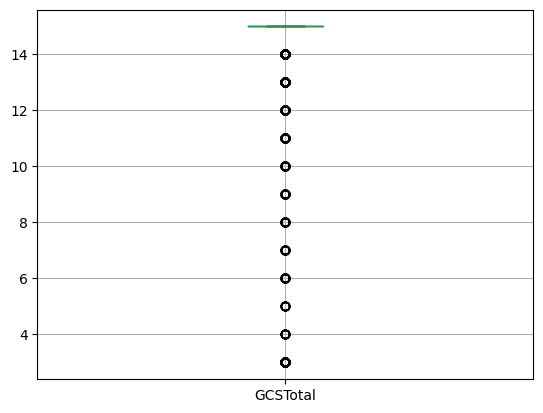

In [333]:
df.boxplot(column = "GCSTotal")

I'm going to pause here because I realized that we should probably do a train-validate-test split for the dataset before I keep going. I did not see anything in the description of the variables that would indicate that we have a way of separating the patients by hospital or by time, so I will do a random split.

In [334]:
#I have a better way now
#dtrain, dtest = train_test_split(df, test_size=0.2 , shuffle = True) # 20% of data to test
#dtrain, dvalidate = train_test_split(dtrain, test_size=0.375) # 5/8 of dtrain, which is 50% overall, to training

# Sanity Check
len(dtrain) / len(df)

0.49998847899721194

<Axes: >

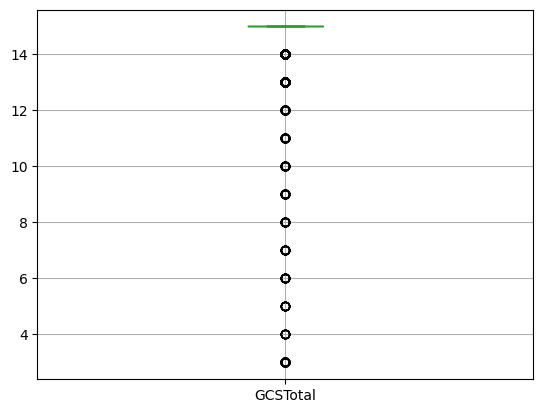

In [335]:
dtrain.boxplot(column = "GCSTotal")

Now, we can continue. What is the distribution of ages in the data? Let's look at the AgeInMonths, since it gives us a finer unit of measurement.

<Axes: ylabel='Frequency'>

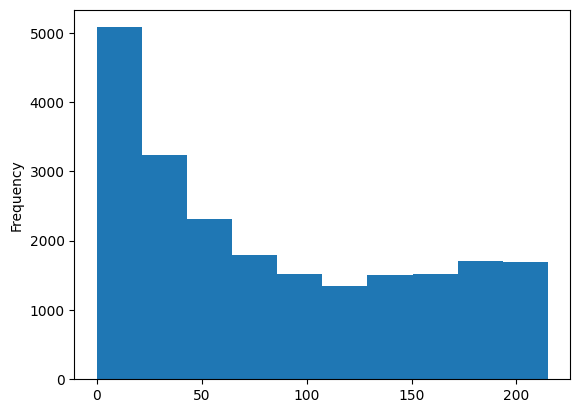

In [336]:
dtrain["AgeInMonth"].plot.hist()

Is there anyone who's ages disagree? e.g. AgeInMonth = 26, AgeInYear = 1

In [337]:
sum((dtrain["AgeInMonth"] / 12).apply(math.floor) != dtrain["AgeinYears"])

0

<Axes: xlabel='AgeTwoPlus'>

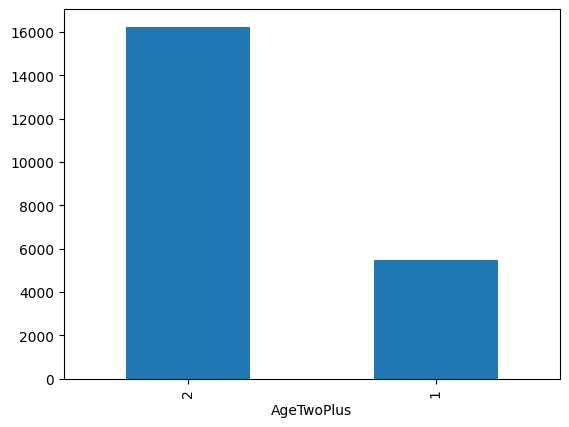

In [338]:
dtrain["AgeTwoPlus"].value_counts().plot.bar()

So, it appears that roughly 1/4 of our train data is under the age of 2. Are there any missing values in this column?

In [339]:
dtrain["AgeTwoPlus"].isnull().sum()

np.int64(0)

When trying to plot the age by gender I got an error that told me there may be a missing value in the gender variable, let's take a look.

In [340]:
dtrain[dtrain["Gender"].isnull()][["PatNum", "Gender", "AgeinYears", "GCSTotal", "CTDone", "PosIntFinal"]]

,PatNum,Gender,AgeinYears,GCSTotal,CTDone,PosIntFinal
7821,7822,NaN,5,15,0,0.0
39698,39699,NaN,15,15,1,0.0


This person did not seem to have any major trauma due to their GCS total. One person was given a CT scan and they were not assesed to have an ciTBI. I will remove this person from the data set. This does mean that I have to pass down this judgement call onto validation and test. If there is a patient with a missing gender, I will remove that patient.


__PatNum?__ I just noticed that, while the data documentation says that PatNum is a randomly generated number, they clearly start at one and increase from there. This makes me wonder if the data is ordered temporally from the get go, and maybe I should not do a random split...

I also just realized that the article describes how they excluded anyone with a GCS less than 14, leaving 42412 patients. Let's check that this agrees with our overall data.

In [341]:
len(df[df.GCSGroup == 2])

42430

I forgot about the 18 patient's excluded because they had missing "primary outcomes," (the article does not elaborate on what this is...) so our result matches the article's. However, if I want to match the analysis the paper does, how do I identify the 18 patients that were excluded?

In [342]:
low_risk = df[df.GCSGroup == 2]
low_risk.PosIntFinal.isnull().sum()

np.int64(18)

I'm going to assume that the final outcome of ciTBI was the "primary outcome" and these are the 18 patients that were excluded from the dataset.

In [343]:
df.PosIntFinal.isnull().sum()

np.int64(20)

Also, since I'm morbidly curious:

In [344]:
df["DeathTBI"].sum()

np.float64(66.0)

In [345]:
low_risk.DeathTBI.sum()

np.float64(0.0)

In [346]:
for j in range(0, 100, 20):
    j_next = j + 19
    print(df.iloc[:, j:j_next].describe())
print(df.iloc[:, 120:125].describe())

             PatNum      EmplType  Certification    InjuryMech  \
count  43399.000000  43381.000000   43399.000000  43098.000000   
mean   21700.000000      3.996750       3.984055     13.905146   
std    12528.356503      1.161454      11.178135     22.697257   
min        1.000000      1.000000       1.000000      1.000000   
25%    10850.500000      3.000000       2.000000      6.000000   
50%    21700.000000      5.000000       3.000000      8.000000   
75%    32549.500000      5.000000       3.000000     10.000000   
max    43399.000000      5.000000      90.000000     90.000000   

       High_impact_InjSev  Amnesia_verb   LOCSeparate        LocLen  \
count        43065.000000  41103.000000  41507.000000  40843.000000   
mean             1.986555     32.888159      0.213313     82.578532   
std              0.565865     43.603687      0.514553     27.517329   
min              1.000000      0.000000      0.000000      1.000000   
25%              2.000000      0.000000      0.000

<Axes: xlabel='AgeinYears'>

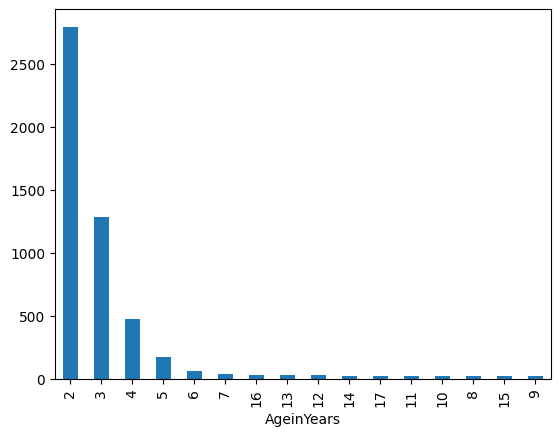

In [347]:
df[(df.AgeTwoPlus == 2) & (df.Amnesia_verb == 91)]["AgeinYears"].value_counts().plot.bar()

The above graphic makes sens. The patients that most of the nonverbal/preverbal would be younger.

<Axes: xlabel='AgeinYears'>

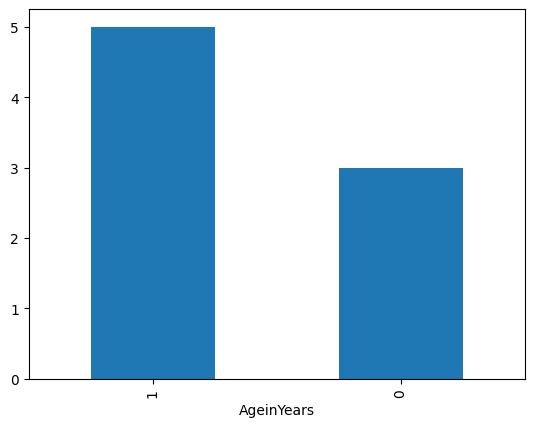

In [348]:
df[(df.AgeTwoPlus == 1) & (df.Amnesia_verb == 1)]["AgeinYears"].value_counts().plot.bar()

This graphic seems to contradict what is in the article. It said patients under two years would not get marked for amnesia, but here are 8 such patients.

In [349]:
df[(df.AgeTwoPlus == 1) & (df.Amnesia_verb == 1)]["GCSTotal"]

1557     15
5546     15
5970     15
16485    15
23151    15
30413    14
32205    15
39271    14
Name: GCSTotal, dtype: int64

And they have very low GCS scores... So why were they treated differently? 

Also, I think I just realized that the PatNum is randomly assigned to a patient. I'm going to assume that each patient was randomly assigned a number, and then the observations were placed in descending order based on their number. In this way, the patients are not arranged temporally, nor are the patients used for validation in the Kupperman article placed at the end of the dataset. I will resume using my train-validation-test split from here on out. Lastly, I set the seed at the beginning and reran the code so that my split during this exploration will be the same.

In [350]:
dtrain.isnull().sum().sum()

np.int64(32552)

Text(0.5, 1.0, 'Top 10 Variables with the Most Missing Values')

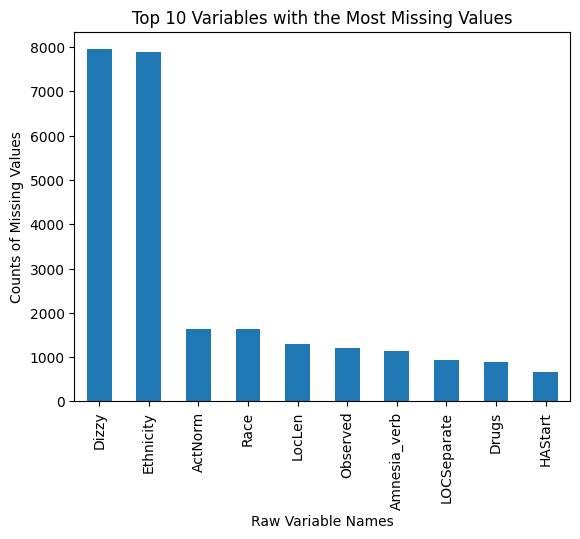

In [351]:
dtrain.isnull().sum().sort_values(ascending = False).head(10).plot.bar()
plt.xlabel("Raw Variable Names")
plt.ylabel("Counts of Missing Values")
plt.title("Top 10 Variables with the Most Missing Values")

<Axes: >

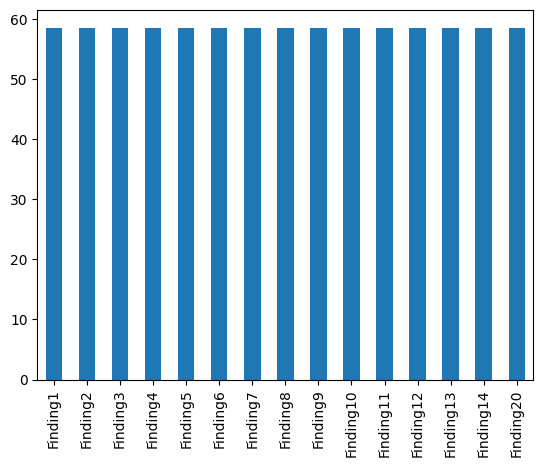

In [352]:
dtrain.loc[:, 'Finding1':'Finding20'].mean().plot.bar()

In [353]:
dtrain.loc[dtrain["LOCSeparate"] == 0, "LOCSeparate":"LocLen"].min()

LOCSeparate     0.0
LocLen         92.0
dtype: float64

In [354]:
dtrain.loc[dtrain["Seiz"] == 0, "Seiz":"SeizLen"].min()

Seiz          0.0
SeizOccur    92.0
SeizLen      92.0
dtype: float64

In [355]:
dtrain.loc[dtrain["HA_verb"] == 0, "HA_verb":"HAStart"].min()

HA_verb        0.0
HASeverity    92.0
HAStart       92.0
dtype: float64

In [356]:
dtrain.loc[dtrain["Vomit"] == 0, "Vomit":"VomitLast"].min()

Vomit          0.0
VomitNbr      92.0
VomitStart    92.0
VomitLast     92.0
dtype: float64

In [357]:
dtrain.loc[dtrain["AMS"] == 0, "AMS":"AMSOth"].min()

AMS             0.0
AMSAgitated    92.0
AMSSleep       92.0
AMSSlow        92.0
AMSRepeat      92.0
AMSOth         92.0
dtype: float64

In [358]:
dtrain.loc[dtrain["SFxBas"] == 0, "SFxBas":"SFxBasRhi"].min()

SFxBas        0.0
SFxBasHem    92.0
SFxBasOto    92.0
SFxBasPer    92.0
SFxBasRet    92.0
SFxBasRhi    92.0
dtype: float64

In [359]:
dtrain.loc[dtrain["SFxPalp"] == 0, "SFxPalp":"SFxPalpDepress"].min()

SFxPalp            0.0
SFxPalpDepress    92.0
dtype: float64

In [360]:
dtrain.loc[dtrain["Hema"] == 0, "Hema":"HemaSize"].min()

Hema         0.0
HemaLoc     92.0
HemaSize    92.0
dtype: float64

In [361]:
dtrain.loc[dtrain["Clav"] == 0, "Clav":"ClavTem"].min()

Clav         0.0
ClavFace    92.0
ClavNeck    92.0
ClavFro     92.0
ClavOcc     92.0
ClavPar     92.0
ClavTem     92.0
dtype: float64

In [362]:
dtrain.loc[dtrain["NeuroD"] == 0, "NeuroD":"NeuroDOth"].min()

NeuroD            0.0
NeuroDMotor      92.0
NeuroDSensory    92.0
NeuroDCranial    92.0
NeuroDReflex     92.0
NeuroDOth        92.0
dtype: float64

In [363]:
dtrain.loc[dtrain["OSI"] == 0, "OSI":"OSIOth"].min()

OSI              0.0
OSIExtremity    92.0
OSICut          92.0
OSICspine       92.0
OSIFlank        92.0
OSIAbdomen      92.0
OSIPelvis       92.0
OSIOth          92.0
dtype: float64

In [364]:
dtrain.loc[dtrain["CTForm1"] == 0, "CTForm1":"CTSedOth"].min()

CTForm1           0.0
IndAge           92.0
IndAmnesia       92.0
IndAMS           92.0
IndClinSFx       92.0
IndHA            92.0
IndHema          92.0
IndLOC           92.0
IndMech          92.0
IndNeuroD        92.0
IndRqstMD        92.0
IndRqstParent    92.0
IndRqstTrauma    92.0
IndSeiz          92.0
IndVomit         92.0
IndXraySFx       92.0
IndOth           92.0
CTSed            92.0
CTSedAgitate     92.0
CTSedAge         92.0
CTSedRqst        92.0
CTSedOth         92.0
dtype: float64

In [365]:
dtrain.loc[dtrain["CTDone"] == 0, "CTDone":"Finding23"].min()

CTDone        0
EDCT         92
PosCT        92
Finding1     92
Finding2     92
Finding3     92
Finding4     92
Finding5     92
Finding6     92
Finding7     92
Finding8     92
Finding9     92
Finding10    92
Finding11    92
Finding12    92
Finding13    92
Finding14    92
Finding20    92
Finding21    92
Finding22    92
Finding23    92
dtype: int64

Check information about race/ethnicity below

In [366]:
a = ((dtrain["Race"] == 1) & dtrain["Ethnicity"].isnull()).sum()
a

np.int64(4137)

In [367]:
b = ((dtrain["Race"] == 1) & (dtrain["Ethnicity"] == 1)).sum()
b

np.int64(1182)

In [368]:
c = ((dtrain["Race"] == 1) & (dtrain["Ethnicity"] == 2)).sum()
c

np.int64(5538)

In [369]:
d = (dtrain["Race"] == 1).sum()
d

np.int64(10857)

In [370]:
a + b + c

np.int64(10857)

In [371]:
(dtrain["Ethnicity"] == 1).sum()

np.int64(2649)

In [372]:
dtrain.shape

(21699, 125)

In [373]:
(dtrain["Ethnicity"] == 1).sum()/ dtrain["Ethnicity"].notnull().sum()

np.float64(0.1917203445031483)

In [374]:
dtrain.shape

(21699, 125)

Im making the judgement call not to remove rows with missing ethnicities or to impute them. I fear imputing them with the mode would drastically skew the data in a way that does not accurately reflect the reality. Additionally, there were so many missing values, that removing all rows that are missing their Ethnicity would gut the dataset by a lot. So, I've decided to keep missing values. However, this means that I will keep the missing values for the rest of the data as well.

In [375]:
dtrain.Gender.isnull().sum()

np.int64(2)

In [376]:
(dtrain["Race"] == 90).sum()

np.int64(684)

## Cleaned Data

From here on out, I'm going to be working with the cleaned data

In [377]:
ctrain = clean.clean_data(dtrain)
ctrain.head(6)

,patnum,empltype,certification,injurymech,highimpactinjsev,amnesiaverb,locseparate,loclen,seiz,seizoccur,...,finding21,finding22,finding23,deathtbi,hosphead,hospheadposct,intub24head,neurosurgery,posintfinal,verbal
40948,40949.0,5.0,3,8.0,2.0,NaN,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0
28351,28352.0,3.0,2,6.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,1.0
30767,30768.0,5.0,2,8.0,2.0,NaN,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0
23675,23676.0,2.0,3,10.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,1.0
24128,24129.0,5.0,3,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,1.0
38630,38631.0,5.0,2,9.0,2.0,NaN,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0


In [378]:
ctrain["verbal"].dtype  # check the data type

dtype('float64')

In [379]:
ctrain.groupby("empltype")["posintfinal"].sum()

empltype
1.0     10.0
2.0      1.0
3.0     79.0
4.0     51.0
5.0    208.0
Name: posintfinal, dtype: float64

In [380]:
ctrain["posintfinal"].describe()

count    21690.000000
mean         0.016090
std          0.125826
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: posintfinal, dtype: float64

<Axes: ylabel='Frequency'>

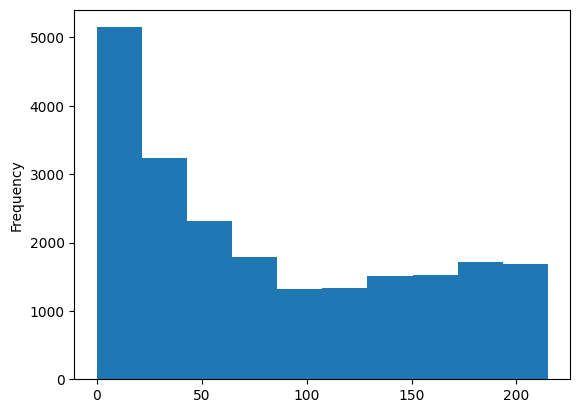

In [381]:
ctrain["ageinmonth"].plot.hist()

<Axes: xlabel='gender'>

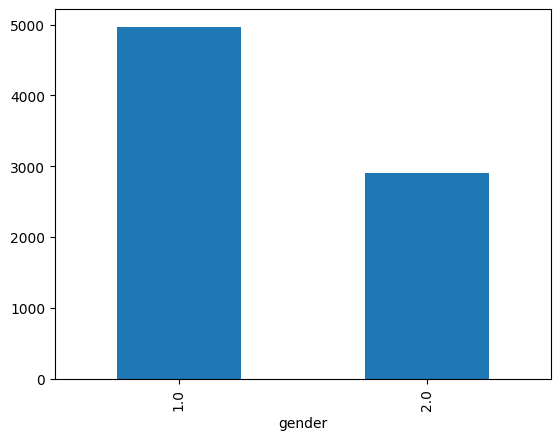

In [382]:
ctrain.groupby("gender")["ctdone"].sum().plot.bar()

<Axes: xlabel='race'>

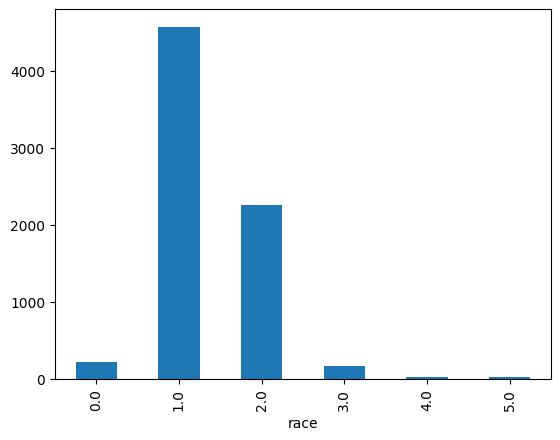

In [383]:
ctrain.groupby("race")["ctdone"].sum().plot.bar()

<Axes: xlabel='ethnicity'>

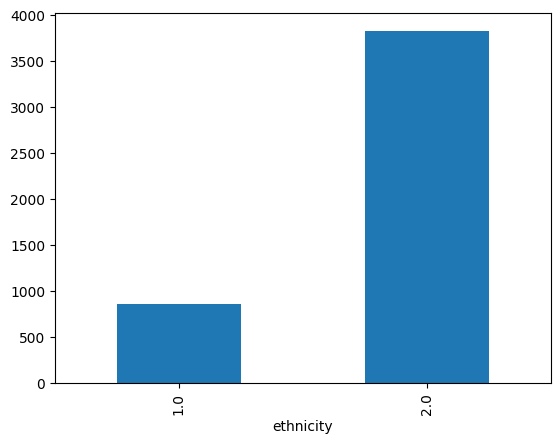

In [384]:
ctrain.groupby("ethnicity")["ctdone"].sum().plot.bar()

<Axes: xlabel='ageinyears'>

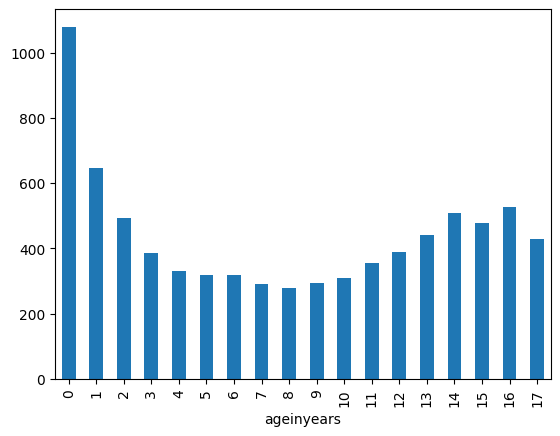

In [385]:
ctrain.groupby("ageinyears")["ctdone"].sum().plot.bar()

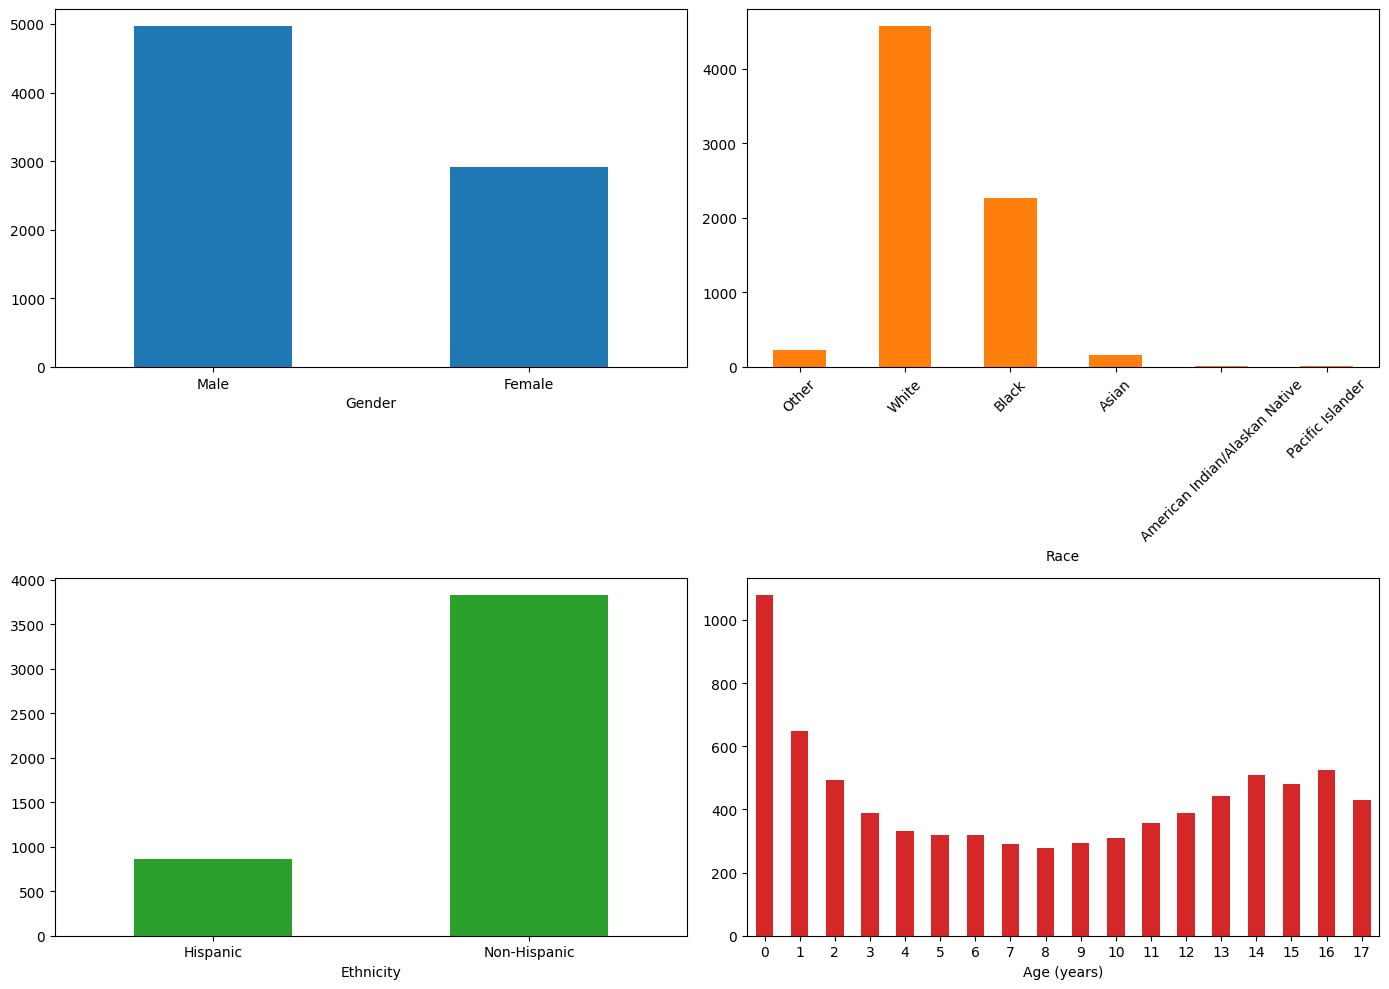

In [386]:


agg_gender = ctrain.groupby("gender")["ctdone"].sum()
agg_race = ctrain.groupby("race")["ctdone"].sum()
agg_eth = ctrain.groupby("ethnicity")["ctdone"].sum()
agg_age = ctrain.groupby("ageinyears")["ctdone"].sum()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ax = axes.ravel()

agg_gender.plot(kind="bar", ax=ax[0], color="C0")
ax[0].set_xlabel("Gender")
gender_map = {1: "Male", 2: "Female"}
ax[0].set_xticklabels([gender_map.get(int(x), str(x)) for x in agg_gender.index], rotation=0)

agg_race.plot(kind="bar", ax=ax[1], color="C1")
ax[1].set_xlabel("Race")
race_map = {0: "Other", 1: "White", 2: "Black", 3: "Asian", 4: "American Indian/Alaskan Native", 5: "Pacific Islander"}
ax[1].set_xticklabels([race_map.get(int(x), str(x)) for x in agg_race.index], rotation=45)

agg_eth.plot(kind="bar", ax=ax[2], color="C2")
ax[2].set_xlabel("Ethnicity")
eth_map = {1: "Hispanic", 2: "Non-Hispanic"}
ax[2].set_xticklabels([eth_map.get(int(x), str(x)) for x in agg_eth.index], rotation=0)

agg_age.plot(kind="bar", ax=ax[3], color="C3")
ax[3].set_xlabel("Age (years)")
ax[3].set_xticklabels([str(int(x)) for x in agg_age.index], rotation=0)

plt.tight_layout()
plt.show()

While pretty, the above plots are not comparable, since they're on absolute scales.

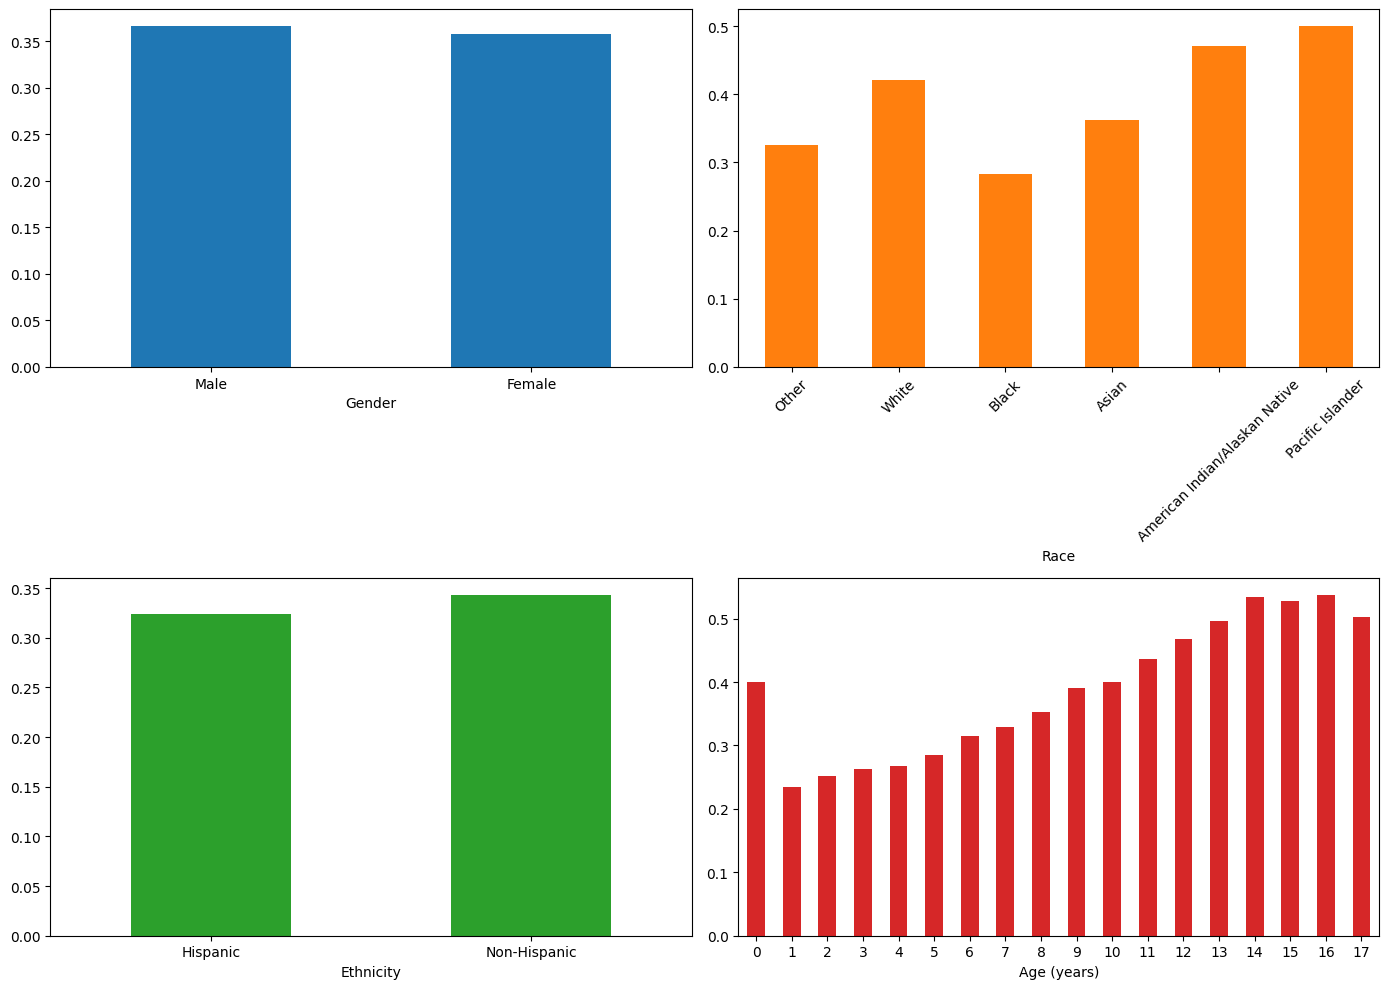

In [387]:
tot_gender = ctrain["gender"].value_counts()
tot_race = ctrain["race"].value_counts()
tot_eth = ctrain["ethnicity"].value_counts()
tot_age = ctrain["ageinyears"].value_counts()

agg_gender = ctrain.groupby("gender")["ctdone"].sum() / tot_gender
agg_race = ctrain.groupby("race")["ctdone"].sum() / tot_race
agg_eth = ctrain.groupby("ethnicity")["ctdone"].sum() / tot_eth
agg_age = ctrain.groupby("ageinyears")["ctdone"].sum() / tot_age

tot_gender = ctrain["gender"].value_counts()
tot_race = ctrain["race"].value_counts()
tot_eth = ctrain["ethnicity"].value_counts()
tot_age = ctrain["ageinyears"].value_counts()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ax = axes.ravel()

agg_gender.plot(kind="bar", ax=ax[0], color="C0")
ax[0].set_xlabel("Gender")
gender_map = {1: "Male", 2: "Female"}
ax[0].set_xticklabels([gender_map.get(int(x), str(x)) for x in agg_gender.index], rotation=0)

agg_race.plot(kind="bar", ax=ax[1], color="C1")
ax[1].set_xlabel("Race")
race_map = {0: "Other", 1: "White", 2: "Black", 3: "Asian", 4: "American Indian/Alaskan Native", 5: "Pacific Islander"}
ax[1].set_xticklabels([race_map.get(int(x), str(x)) for x in agg_race.index], rotation=45)

agg_eth.plot(kind="bar", ax=ax[2], color="C2")
ax[2].set_xlabel("Ethnicity")
eth_map = {1: "Hispanic", 2: "Non-Hispanic"}
ax[2].set_xticklabels([eth_map.get(int(x), str(x)) for x in agg_eth.index], rotation=0)

agg_age.plot(kind="bar", ax=ax[3], color="C3")
ax[3].set_xlabel("Age (years)")
ax[3].set_xticklabels([str(int(x)) for x in agg_age.index], rotation=0)

plt.tight_layout()
plt.show()

In [388]:
tot_gender = ctrain["gender"].value_counts()
tot_gender

gender
1.0    13562
2.0     8135
Name: count, dtype: int64

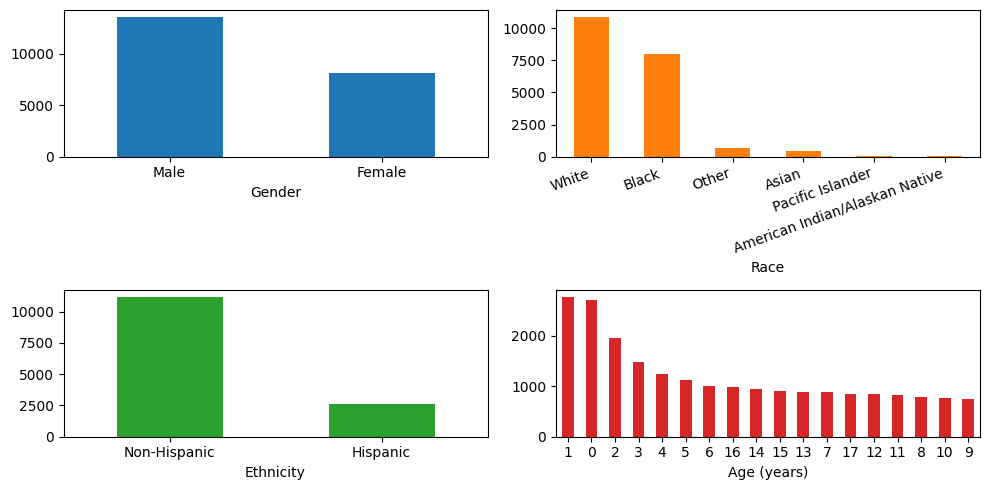

In [389]:


agg_gender = ctrain["gender"].value_counts()
agg_race = ctrain["race"].value_counts()
agg_eth = ctrain["ethnicity"].value_counts()
agg_age = ctrain["ageinyears"].value_counts()

fig, axes = plt.subplots(2, 2, figsize=(10, 5))
ax = axes.ravel()

agg_gender.plot(kind="bar", ax=ax[0], color="C0")
ax[0].set_xlabel("Gender")
gender_map = {1: "Male", 2: "Female"}
ax[0].set_xticklabels([gender_map.get(int(x), str(x)) for x in agg_gender.index], rotation=0)

agg_race.plot(kind="bar", ax=ax[1], color="C1")
ax[1].set_xlabel("Race")
race_map = {0: "Other", 1: "White", 2: "Black", 3: "Asian", 4: "American Indian/Alaskan Native", 5: "Pacific Islander"}
ax[1].set_xticklabels([race_map.get(int(x), str(x)) for x in agg_race.index], rotation=20, ha="right")

agg_eth.plot(kind="bar", ax=ax[2], color="C2")
ax[2].set_xlabel("Ethnicity")
eth_map = {1: "Hispanic", 2: "Non-Hispanic"}
ax[2].set_xticklabels([eth_map.get(int(x), str(x)) for x in agg_eth.index], rotation=0)

agg_age.plot(kind="bar", ax=ax[3], color="C3")
ax[3].set_xlabel("Age (years)")
ax[3].set_xticklabels([str(int(x)) for x in agg_age.index], rotation=0)

plt.tight_layout()
plt.show()

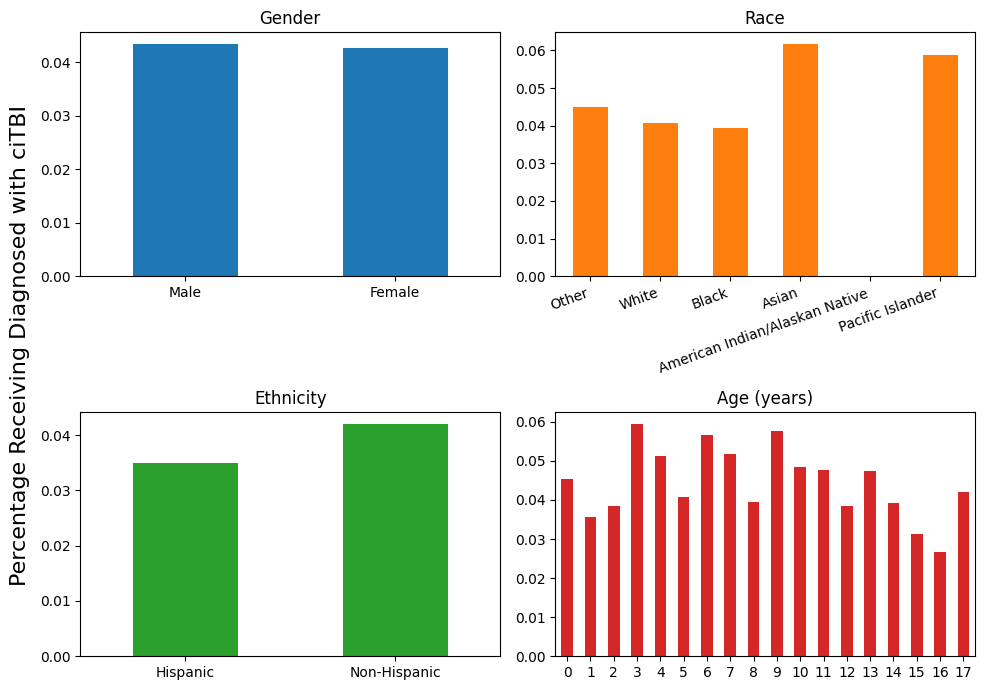

In [390]:
tot_gender = ctrain[ctrain["ctdone"] == 1]["gender"].value_counts()
tot_race = ctrain[ctrain["ctdone"] == 1]["race"].value_counts()
tot_eth = ctrain[ctrain["ctdone"] == 1]["ethnicity"].value_counts()
tot_age = ctrain[ctrain["ctdone"] == 1]["ageinyears"].value_counts()

agg_gender = ctrain[ctrain["ctdone"] == 1].groupby("gender")["posintfinal"].sum() / tot_gender
agg_race = ctrain[ctrain["ctdone"] == 1].groupby("race")["posintfinal"].sum() / tot_race
agg_eth = ctrain[ctrain["ctdone"] == 1].groupby("ethnicity")["posintfinal"].sum() / tot_eth
agg_age = ctrain[ctrain["ctdone"] == 1].groupby("ageinyears")["posintfinal"].sum() / tot_age

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
ax = axes.ravel()

agg_gender.plot(kind="bar", ax=ax[0], color="C0")
ax[0].set_title("Gender")
ax[0].set_xlabel("")
gender_map = {1: "Male", 2: "Female"}
ax[0].set_xticklabels([gender_map.get(int(x), str(x)) for x in agg_gender.index], rotation=0)

agg_race.plot(kind="bar", ax=ax[1], color="C1")
ax[1].set_title("Race")
ax[1].set_xlabel("")
race_map = {0: "Other", 1: "White", 2: "Black", 3: "Asian", 4: "American Indian/Alaskan Native", 5: "Pacific Islander"}
ax[1].set_xticklabels([race_map.get(int(x), str(x)) for x in agg_race.index], rotation=20, ha="right")

agg_eth.plot(kind="bar", ax=ax[2], color="C2")
ax[2].set_title("Ethnicity")
eth_map = {1: "Hispanic", 2: "Non-Hispanic"}
ax[2].set_xticklabels([eth_map.get(int(x), str(x)) for x in agg_eth.index], rotation=0)
ax[2].set_xlabel("")

agg_age.plot(kind="bar", ax=ax[3], color="C3")
ax[3].set_title("Age (years)")
ax[3].set_xlabel("")
ax[3].set_xticklabels([str(int(x)) for x in agg_age.index], rotation=0)

fig.supylabel("Percentage Receiving Diagnosed with ciTBI", fontsize = 16)
plt.tight_layout()
plt.show()

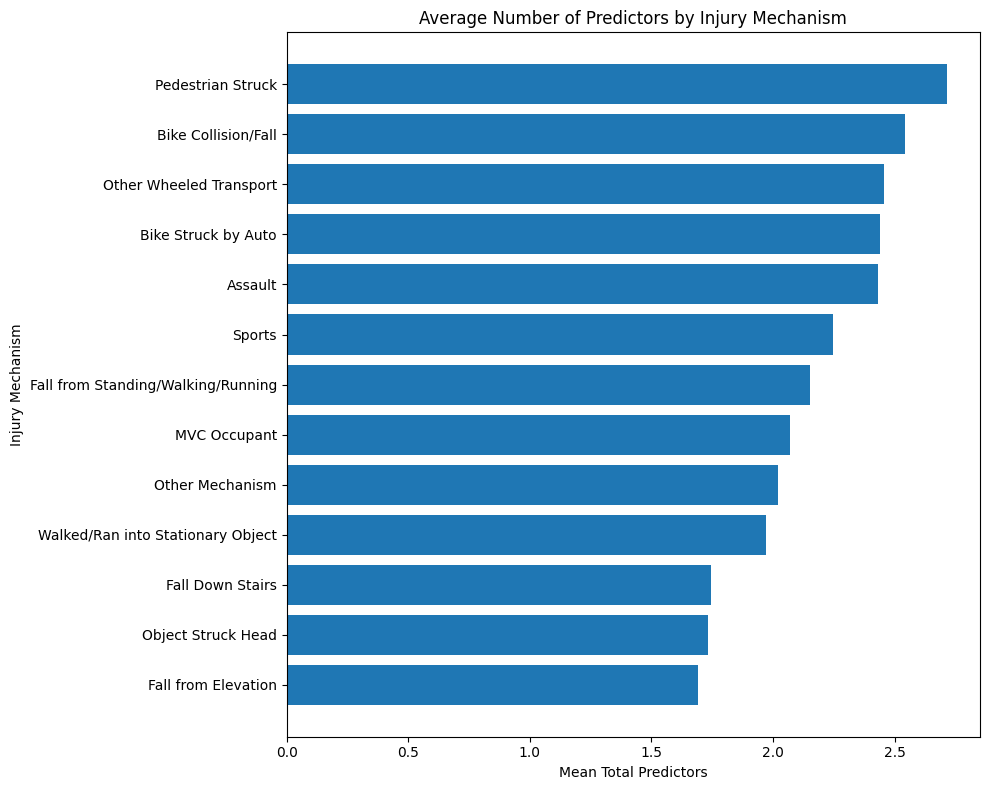

In [391]:
primary = ["locseparate", "seiz", "haverb", "vomit", "ams", "sfxbas", "sfxpalp", "hema", "clav", "neurod", "osi"]

ctrain["totalpreds"] = ctrain.loc[:, primary].sum(axis=1)

injury_means = ctrain.groupby("injurymech")["totalpreds"].mean().sort_values(ascending=True)

# Map injury mechanism codes to labels
injury_map = {
    1: "MVC Occupant",
    2: "Pedestrian Struck",
    3: "Bike Struck by Auto",
    4: "Bike Collision/Fall",
    5: "Other Wheeled Transport",
    6: "Fall from Standing/Walking/Running",
    7: "Walked/Ran into Stationary Object",
    8: "Fall from Elevation",
    9: "Fall Down Stairs",
    10: "Sports",
    11: "Assault",
    12: "Object Struck Head",
    0: "Other Mechanism"
}

# Create labels
labels = [injury_map.get(int(x), str(int(x))) for x in injury_means.index]

plt.figure(figsize=(10, 8))
plt.barh(range(len(injury_means)), injury_means.values, color="C0")
plt.yticks(range(len(injury_means)), labels)
plt.xlabel("Mean Total Predictors")
plt.ylabel("Injury Mechanism")
plt.title("Average Number of Predictors by Injury Mechanism")
plt.tight_layout()
plt.show()

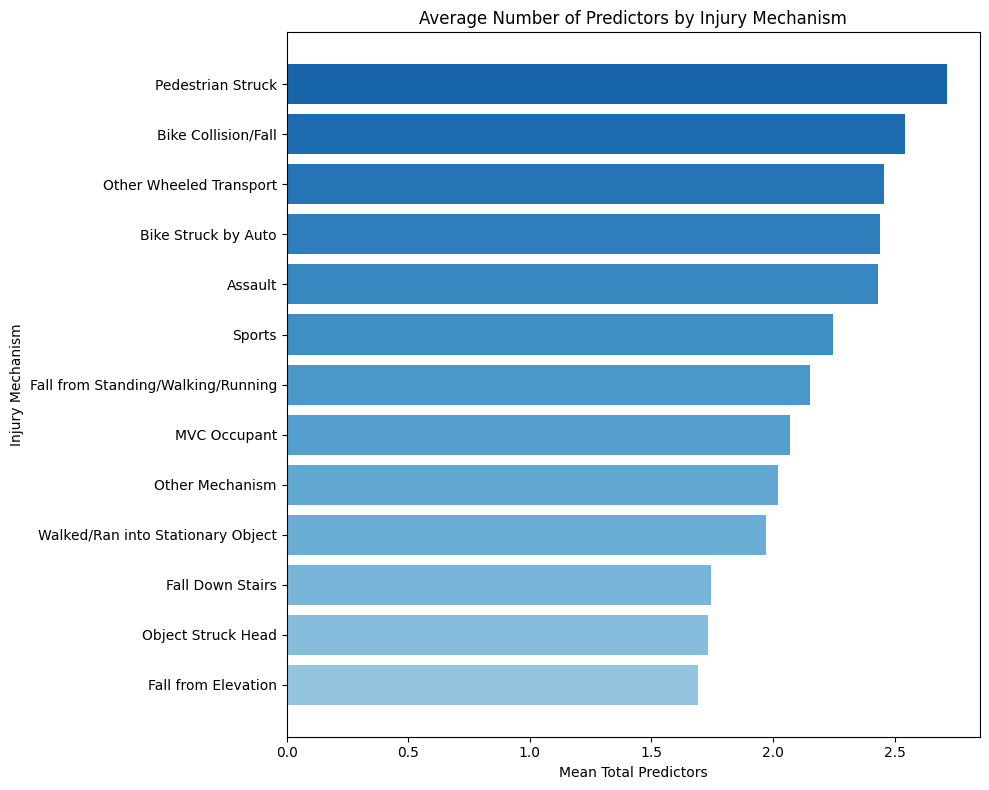

In [392]:
primary = ["locseparate", "seiz", "haverb", "vomit", "ams", "sfxbas", "sfxpalp", "hema", "clav", "neurod", "osi"]

ctrain["totalpreds"] = ctrain.loc[:, primary].sum(axis=1)

injury_means = ctrain.groupby("injurymech")["totalpreds"].mean().sort_values(ascending=True)

# Map injury mechanism codes to labels
injury_map = {
    1: "MVC Occupant",
    2: "Pedestrian Struck",
    3: "Bike Struck by Auto",
    4: "Bike Collision/Fall",
    5: "Other Wheeled Transport",
    6: "Fall from Standing/Walking/Running",
    7: "Walked/Ran into Stationary Object",
    8: "Fall from Elevation",
    9: "Fall Down Stairs",
    10: "Sports",
    11: "Assault",
    12: "Object Struck Head",
    0: "Other Mechanism"
}

# Create labels
labels = [injury_map.get(int(x), str(int(x))) for x in injury_means.index]

# Create gradient colors from light to dark
colors = plt.cm.Blues(np.linspace(0.4, 0.8, len(injury_means)))

plt.figure(figsize=(10, 8))
plt.barh(range(len(injury_means)), injury_means.values, color=colors)
plt.yticks(range(len(injury_means)), labels)
plt.xlabel("Mean Total Predictors")
plt.ylabel("Injury Mechanism")
plt.title("Average Number of Predictors by Injury Mechanism")
plt.tight_layout()
plt.show()

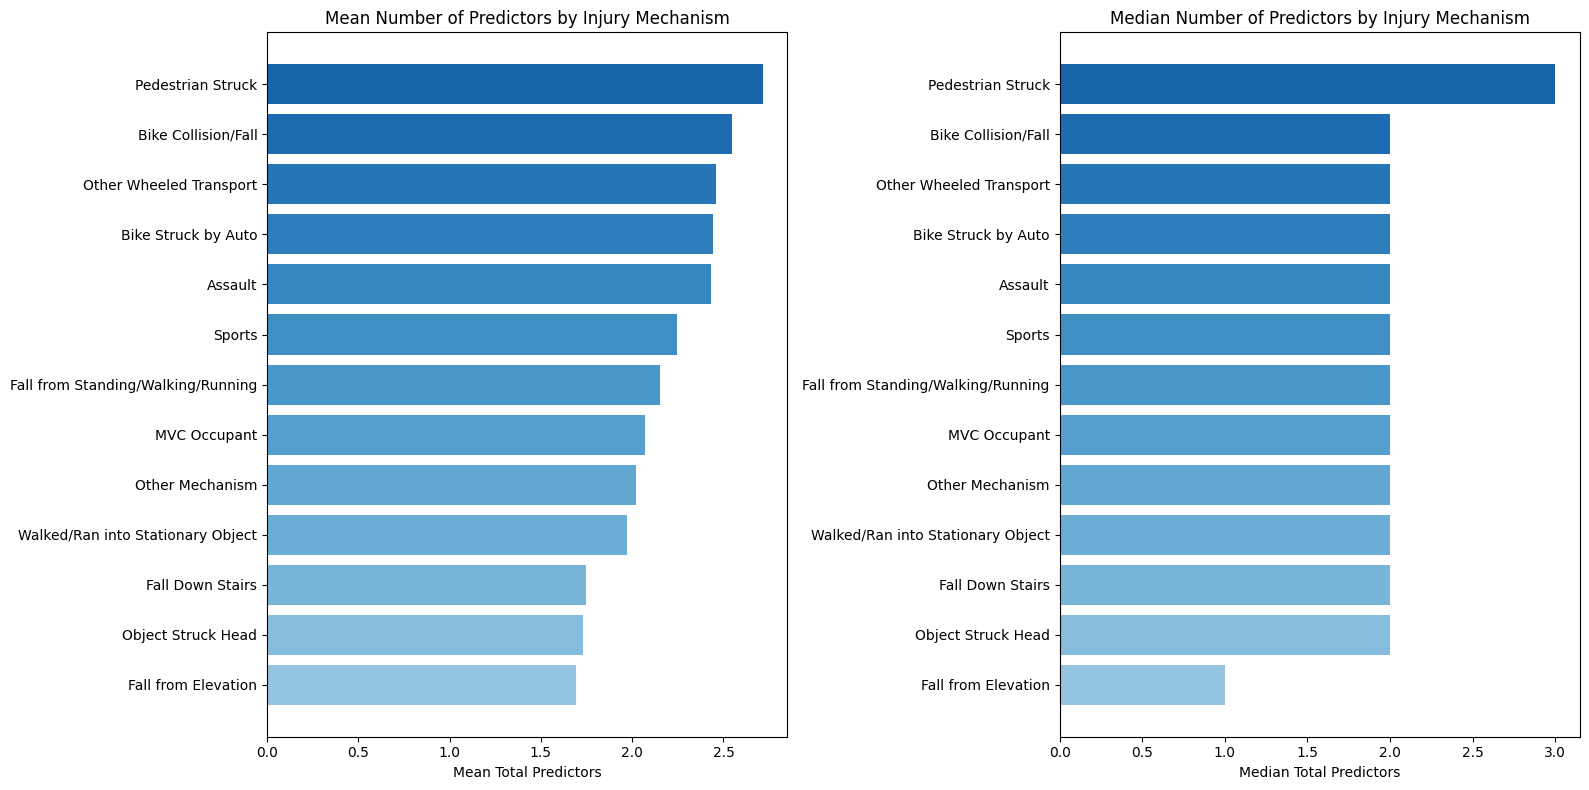

In [393]:
primary = ["locseparate", "seiz", "haverb", "vomit", "ams", "sfxbas", "sfxpalp", "hema", "clav", "neurod", "osi"]

ctrain["totalpreds"] = ctrain.loc[:, primary].sum(axis=1)

# Calculate mean and median by injury mechanism
injury_means = ctrain.groupby("injurymech")["totalpreds"].mean().sort_values(ascending=True)
injury_medians = ctrain.groupby("injurymech")["totalpreds"].median().loc[injury_means.index]

# Map injury mechanism codes to labels
injury_map = {
    1: "MVC Occupant",
    2: "Pedestrian Struck",
    3: "Bike Struck by Auto",
    4: "Bike Collision/Fall",
    5: "Other Wheeled Transport",
    6: "Fall from Standing/Walking/Running",
    7: "Walked/Ran into Stationary Object",
    8: "Fall from Elevation",
    9: "Fall Down Stairs",
    10: "Sports",
    11: "Assault",
    12: "Object Struck Head",
    0: "Other Mechanism"
}

# Create labels
labels = [injury_map.get(int(x), str(int(x))) for x in injury_means.index]

# Create gradient colors from light to dark
colors = plt.cm.Blues(np.linspace(0.4, 0.8, len(injury_means)))

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Mean plot
axes[0].barh(range(len(injury_means)), injury_means.values, color=colors)
axes[0].set_yticks(range(len(injury_means)))
axes[0].set_yticklabels(labels)
axes[0].set_xlabel("Mean Total Predictors")
axes[0].set_title("Mean Number of Predictors by Injury Mechanism")

# Median plot
axes[1].barh(range(len(injury_medians)), injury_medians.values, color=colors)
axes[1].set_yticks(range(len(injury_medians)))
axes[1].set_yticklabels(labels)
axes[1].set_xlabel("Median Total Predictors")
axes[1].set_title("Median Number of Predictors by Injury Mechanism")

plt.tight_layout()
plt.show()

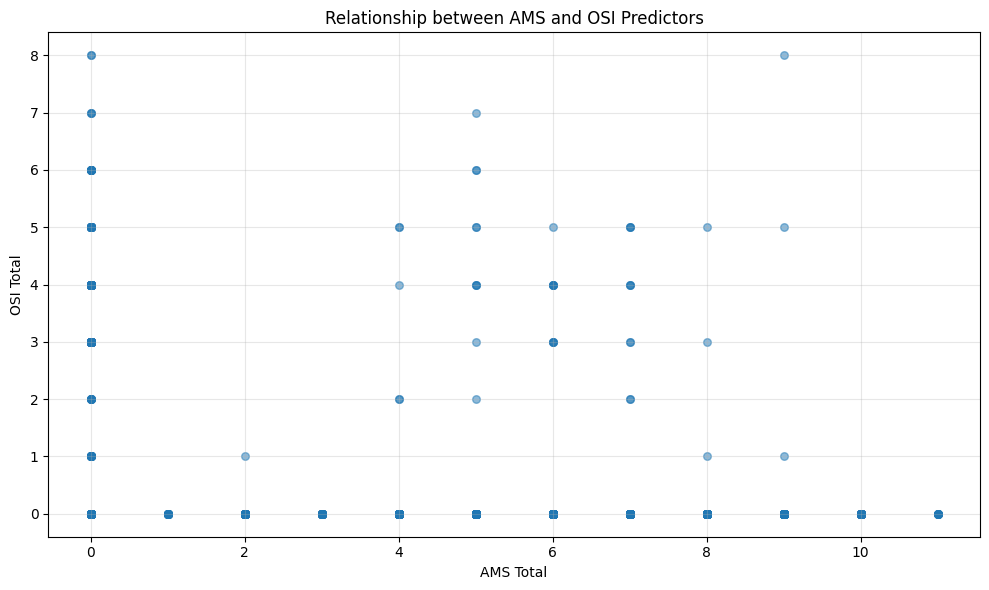

In [394]:
x = ctrain.loc[:, "vomit":"vomitlast"].sum(axis=1)
y = ctrain.loc[:, "seiz":"seizlen"].sum(axis=1)

# Create a DataFrame with x, y, and index
data = pd.DataFrame({
    "x": x,
    "y": y
}, index=ctrain.index)

# Create scatterplot
plt.figure(figsize=(10, 6))
plt.scatter(data["x"], data["y"], alpha=0.5, s=30)
plt.xlabel("AMS Total")
plt.ylabel("OSI Total")
plt.title("Relationship between AMS and OSI Predictors")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

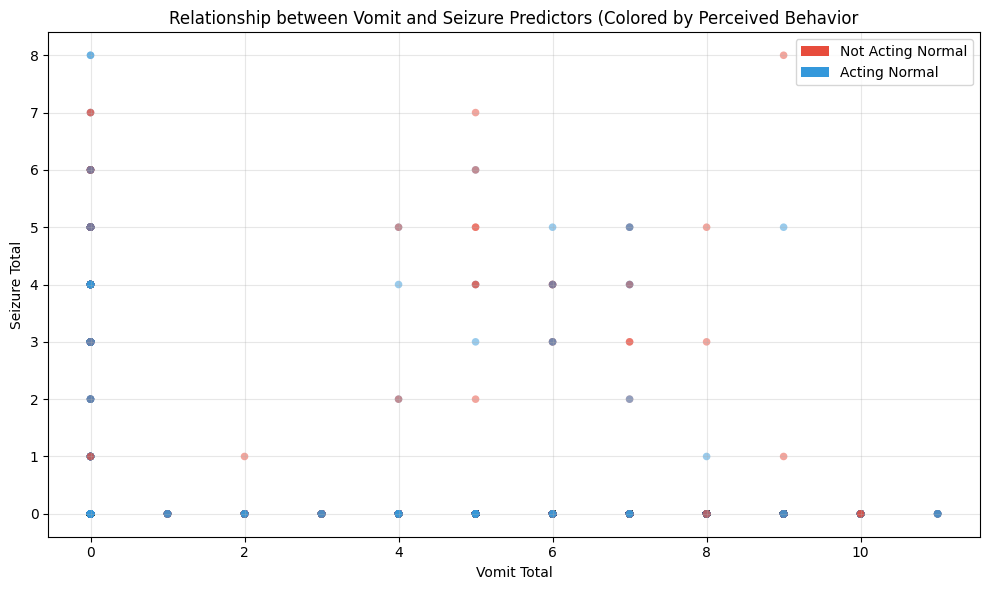

In [395]:
x = ctrain.loc[:, "vomit":"vomitlast"].sum(axis=1)
y = ctrain.loc[:, "seiz":"seizlen"].sum(axis=1)

# Create a DataFrame with x, y, and index
data = pd.DataFrame({
    "x": x,
    "y": y,
    "actnorm": ctrain["actnorm"]
}, index=ctrain.index)

# Create color map based on actnorm (0 or 1)
colors = ["#E74C3C" if val == 0 else "#3498DB" for val in data["actnorm"]]

# Create scatterplot colored by actnorm
plt.figure(figsize=(10, 6))
plt.scatter(data["x"], data["y"], c=colors, alpha=0.5, s=30, edgecolors='none')
plt.xlabel("Vomit Total")
plt.ylabel("Seizure Total")
plt.title("Relationship between Vomit and Seizure Predictors (Colored by Perceived Behavior")
plt.grid(True, alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#E74C3C', label='Not Acting Normal'),
                   Patch(facecolor='#3498DB', label='Acting Normal')]
plt.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

# Action Items

* [x] Remove "AgeinYears" column and change "AgeInMonth" to just "ageinmonths"
* [x] Split data based on "AgeTwoPlus" indicator since we are treating these as separate groups (depends on user input to cleaning function)
* [x] Investigate why there are so many patients with low GCS scores 
* [x] Remove patients with low GCS scores and no primary outcome.
* [x] Remove individuals with missing values for gender if the GCS scores are very low, or high and they were not given a CT scan or found to have a ciTBI. (Decided against this because there are only two patients in the training data with missing values for gender.)
* [x] Identify "Primary outcomes" and figure out how to remove patients with lower than 14 GCS scores and the 18 additional patients.
* [x] Investigate PatNum. Why is it in ascending order? Is data arranged temporally?
* [x] decide how to handle the outliers. (Outliers are the special encodings 90,91,92)
* [x] decide how to handle missing values. (I'm keeping some and changing others.)
* [ ] Find source linking CT scans or exposure to radiation to cancer later in life
* [X] Add paper describing GSC to bibliography.
* [ ] Formally come up with my own model. (Bayesian Dirchlet Multinomial model with uninformative prior?)
* [ ] Drop `GCSTotal` column in preprocesing It is the sum of the individual GCS measurements for eye, verbal, and motor. We can add it back if necessary.
* [ ] Drop `AgeinYears` and `AgeTwoPlus` column in preprocessing `AgeInMonths` provides finer resolution. We can always get both of them back.

## My notes on the Data

1. Observational cohort study taking place at PECARN (pediatric) emergency centers. We want two rules, one for $< 2 \text{ years}$ and one for $2 \text{ years} >=$. Subjects presenting within 24 hours of head trauma with a Glasgow Coma Score of 14-15.

2. We excluded children with trivial injury mechanisms defined by ground-level falls or walking or running into stationary objects, and no signs or symptoms of head trauma other than scalp abrasions and lacerations.  Patients were also excluded if they had penetrating trauma, known brain tumors, pre-existing neurological disorders complicating assessment, or neuroimaging at an outside hospital before transfer.  Patients were excluded if they had ventricular shunts or bleeding disorders. __Does this matter?__

3. We defined clinically-important TBI (ciTBI) a priori as death from TBI, neurosurgery, intubation for more than 24 hours for TBI, or hospital admission of two or more nights for theTBI in association with TBI on CT

4.  To identify missed traumatic brain injuries, research coordinators did standardized telephone surveys of guardians of patients discharged from the emergency department between 7 and 90 days after the emergency department visit. Medical records and imaging results were obtained if a missed traumatic brain injury was suggested at follow-up. If a ciTBI was identified, the patient’s outcome was classified accordingly. If we were unable to contact the patient’s guardian, we reviewed the medical record, emergency department process improvement records, and county morgue records, to ensure that no discharged patient was subsequently diagnosed with ciTBI.